# Analyse SL-CR Experiment Results

Notebook for inspecting the merged ECLYPSE metric output, separating timeout and non-timeout events, and plotting the main Prolog reasoning metrics by topology.

## Setup

The input file is expected to be the merged parquet produced from the experiment logs. Change `RESULTS_PATH` if the file lives elsewhere.

In [49]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

RESULTS_PATH = Path(".") / "myres.parquet"

METRICS = [
    "prolog_query_seconds",
    "prolog_inferences",
    "placement_migrations",
]

TOPOLOGIES = ["ER", "BA", "IAG"]

METRIC_LABELS = {
    "prolog_query_seconds": "Execution time [s]",
    "prolog_inferences": "Prolog inferences",
    "placement_migrations": "Migrations",
}

EVENT_COLS = [
    "event_id",
    "n_event",
    "components",
    "mode",
    "nodes",
    "seed",
    "steps",
    "timeout",
    "topology",
]

## Load and inspect

In [50]:
df = pd.read_parquet(RESULTS_PATH)

print(f"rows: {len(df)}")
print(f"columns: {list(df.columns)}")

display(df.head())

rows: 100
columns: ['timestamp', 'event_id', 'n_event', 'callback_id', 'value', 'components', 'mode', 'nodes', 'seed', 'steps', 'timeout', 'topology']


,timestamp,event_id,n_event,callback_id,value,components,mode,nodes,seed,steps,timeout,topology
0,2026-06-18T16:30:03.436326,enact,1,prolog_query_seconds,3.878384e+00,500,cr,1000,3997,10,300,IAG
1,2026-06-18T16:30:03.436449,enact,1,prolog_inferences,7.205722e+07,500,cr,1000,3997,10,300,IAG
2,2026-06-18T16:30:03.436536,enact,1,placement_migrations,inf,500,cr,1000,3997,10,300,IAG
3,2026-06-18T16:30:03.436619,enact,1,is_mapped,1.000000e+00,500,cr,1000,3997,10,300,IAG
4,2026-06-18T16:30:03.436701,enact,1,query_timeout,0.000000e+00,500,cr,1000,3997,10,300,IAG


In [51]:
metric_counts = df["callback_id"].value_counts().rename_axis("callback_id").reset_index(name="rows")

print("Metric rows")
display(metric_counts)

Metric rows


,callback_id,rows
0,prolog_query_seconds,20
1,prolog_inferences,20
2,placement_migrations,20
3,is_mapped,20
4,query_timeout,20


## Attach timeout status to every metric row

`query_timeout = 1` means that the Prolog query timed out. `query_timeout = 0` means that it completed without timeout. The merge below propagates that event-level status to all metric rows of the same simulation event.

In [52]:
timeout_events = (
    df[df["callback_id"] == "query_timeout"]
    .loc[:, EVENT_COLS + ["value"]]
    .rename(columns={"value": "query_timeout"})
)

timeout_events["query_timeout"] = timeout_events["query_timeout"].astype(int)

df_with_timeout = df.merge(timeout_events, on=EVENT_COLS, how="left", validate="many_to_one")

df_timeout = df_with_timeout[df_with_timeout["query_timeout"] == 1].copy()
df_no_timeout = df_with_timeout[df_with_timeout["query_timeout"] == 0].copy()

summary = pd.DataFrame(
    {
        "dataset": ["all metric rows", "timeout metric rows", "non-timeout metric rows"],
        "rows": [len(df_with_timeout), len(df_timeout), len(df_no_timeout)],
        "events": [
            df_with_timeout[EVENT_COLS].drop_duplicates().shape[0],
            df_timeout[EVENT_COLS].drop_duplicates().shape[0],
            df_no_timeout[EVENT_COLS].drop_duplicates().shape[0],
        ],
    }
)

display(summary)

,dataset,rows,events
0,all metric rows,100,20
1,timeout metric rows,0,0
2,non-timeout metric rows,100,20


## Missing and non-finite values

For plotting, `inf` and `-inf` are treated as missing values. They are not converted to zero, because a missing or invalid metric is different from a measured zero.

In [53]:
quality_df = df_with_timeout.copy()
quality_df["is_nan"] = quality_df["value"].isna()
quality_df["is_inf"] = np.isinf(quality_df["value"])
quality_df["is_bad"] = quality_df["is_nan"] | quality_df["is_inf"]

quality_summary = (
    quality_df.groupby("callback_id", as_index=False)
    .agg(
        rows=("value", "size"),
        nan_values=("is_nan", "sum"),
        inf_values=("is_inf", "sum"),
        bad_values=("is_bad", "sum"),
    )
)

display(quality_summary)

,callback_id,rows,nan_values,inf_values,bad_values
0,is_mapped,20,0,0,0
1,placement_migrations,20,0,2,2
2,prolog_inferences,20,0,0,0
3,prolog_query_seconds,20,0,0,0
4,query_timeout,20,0,0,0


## Optional filters

Leave values as `None` to aggregate over the full grid. Set one or more values to focus on a specific slice, for example `NODES_FILTER = 500` or `COMPONENTS_FILTER = 100`.

In [54]:
NODES_FILTER = None
COMPONENTS_FILTER = None
MODE_FILTER = None
TOPOLOGY_FILTER = None


def apply_filters(data):
    out = data.copy()
    if NODES_FILTER is not None:
        out = out[out["nodes"] == NODES_FILTER]
    if COMPONENTS_FILTER is not None:
        out = out[out["components"] == COMPONENTS_FILTER]
    if MODE_FILTER is not None:
        out = out[out["mode"] == MODE_FILTER]
    if TOPOLOGY_FILTER is not None:
        out = out[out["topology"] == TOPOLOGY_FILTER]
    return out

analysis_df = apply_filters(df_no_timeout)

print(f"non-timeout rows after filters: {len(analysis_df):,}")
display(
    analysis_df[EVENT_COLS]
    .drop_duplicates()
    .groupby(["topology", "mode"], as_index=False)
    .size()
    .rename(columns={"size": "events"})
)

non-timeout rows after filters: 100


,topology,mode,events
0,IAG,base,10
1,IAG,cr,10


## Metric trends on non-timeout events

The trends below use only events with `query_timeout = 0`. Values are averaged across seeds and across any grid dimensions not fixed in the optional filter cell.

In [55]:
plot_df = analysis_df[analysis_df["callback_id"].isin(METRICS)].copy()
plot_df["value"] = plot_df["value"].replace([np.inf, -np.inf], np.nan)

invalid_metric_rows = (
    plot_df[plot_df["value"].isna()]
    .groupby(["callback_id", "topology", "mode"], as_index=False)
    .size()
    .rename(columns={"size": "invalid_rows"})
)

plot_df = plot_df.dropna(subset=["value"])

trend_df = (
    plot_df.groupby(["topology", "mode", "n_event", "callback_id"], as_index=False)
    .agg(
        value_mean=("value", "mean"),
        value_median=("value", "median"),
        n=("value", "count"),
    )
)

print("Invalid metric rows excluded from plots")
display(invalid_metric_rows)

display(trend_df.head())

Invalid metric rows excluded from plots


,callback_id,topology,mode,invalid_rows
0,placement_migrations,IAG,base,1
1,placement_migrations,IAG,cr,1


,topology,mode,n_event,callback_id,value_mean,value_median,n
0,IAG,base,1,prolog_inferences,7.205620e+07,7.205620e+07,1
1,IAG,base,1,prolog_query_seconds,3.882934e+00,3.882934e+00,1
2,IAG,base,2,placement_migrations,4.960000e+02,4.960000e+02,1
3,IAG,base,2,prolog_inferences,1.210509e+08,1.210509e+08,1
4,IAG,base,2,prolog_query_seconds,6.521331e+00,6.521331e+00,1


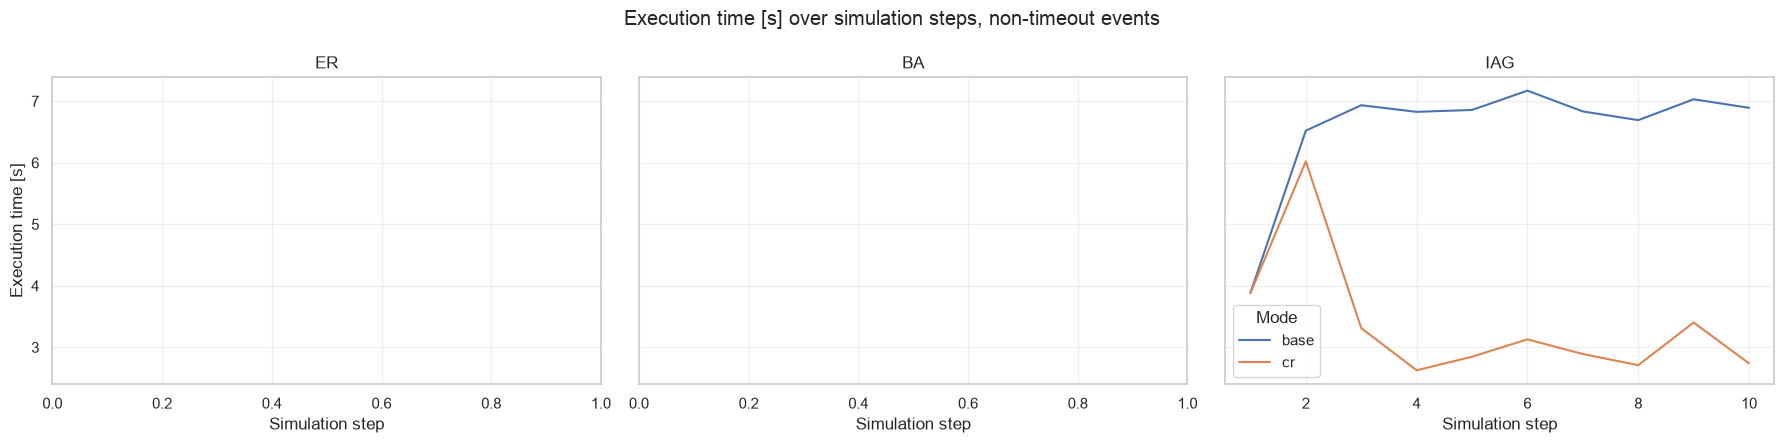

ValueError: cannot convert float NaN to integer

<Figure size 1800x450 with 3 Axes>

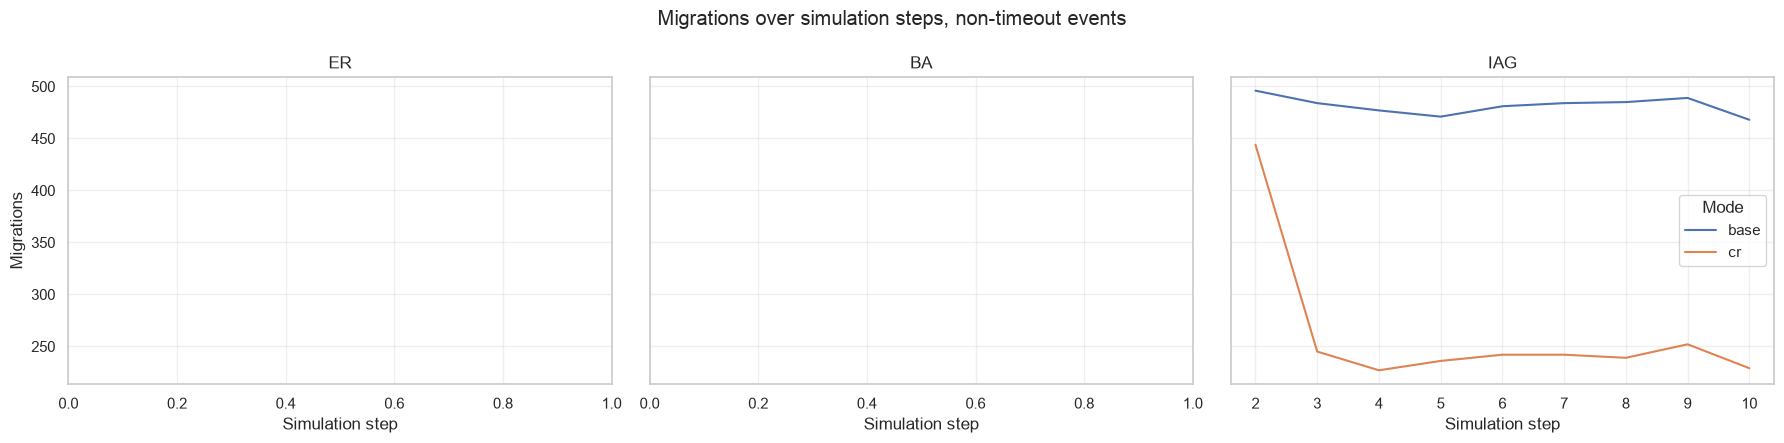

In [56]:
for metric in METRICS:
    fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), sharey=True)

    for ax, topology in zip(axes, TOPOLOGIES):
        data = trend_df[
            (trend_df["callback_id"] == metric)
            & (trend_df["topology"] == topology)
        ]

        sns.lineplot(
            data=data,
            x="n_event",
            y="value_mean",
            hue="mode",
            marker=None,
            ax=ax,
        )

        ax.set_title(topology)
        ax.set_xlabel("Simulation step")
        ax.set_ylabel(METRIC_LABELS[metric])
        ax.grid(True, alpha=0.3)

        if ax.get_legend() is not None:
            ax.legend(title="Mode")

    fig.suptitle(f"{METRIC_LABELS[metric]} over simulation steps, non-timeout events")
    fig.tight_layout()
    plt.show()

## Raw metric line plots by topology and size

These figures use the non-timeout event dataframe directly, after the optional filters, without using `trend_df` and without pre-aggregating values. For each metric and topology, columns are infrastructure sizes (`nodes`) and rows are application sizes (`components`). All subplots in the same figure use exactly the same Y-axis limits and ticks.

Skipping prolog_query_seconds / ER: no finite values available
Skipping prolog_query_seconds / BA: no finite values available


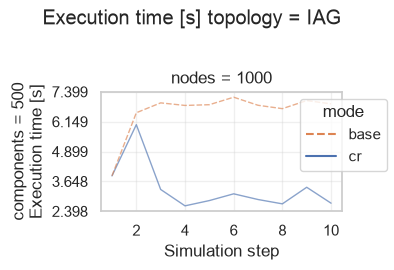

Skipping prolog_inferences / ER: no finite values available
Skipping prolog_inferences / BA: no finite values available


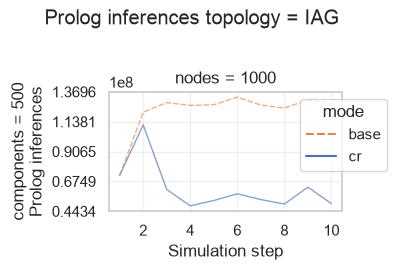

Skipping placement_migrations / ER: no finite values available
Skipping placement_migrations / BA: no finite values available


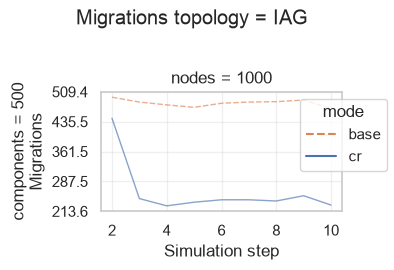

In [57]:
raw_line_df = analysis_df[analysis_df["callback_id"].isin(METRICS)].copy()
raw_line_df["value"] = pd.to_numeric(raw_line_df["value"], errors="coerce")
raw_line_df = raw_line_df[np.isfinite(raw_line_df["value"])].copy()
raw_line_df["run_id"] = raw_line_df["mode"].astype(str) + " / seed=" + raw_line_df["seed"].astype(str)

nodes_values = sorted(raw_line_df["nodes"].dropna().unique())
components_values = sorted(raw_line_df["components"].dropna().unique())

for metric in METRICS:
    for topology in TOPOLOGIES:
        data = raw_line_df[
            (raw_line_df["callback_id"] == metric)
            & (raw_line_df["topology"] == topology)
        ].copy()

        if data.empty:
            print(f"Skipping {metric} / {topology}: no finite values available")
            continue

        y_min = data["value"].min()
        y_max = data["value"].max()
        if y_min == y_max:
            pad = 1 if y_min == 0 else abs(y_min) * 0.05
        else:
            pad = (y_max - y_min) * 0.05
        lower = max(0, y_min - pad)
        upper = y_max + pad
        y_ticks = np.linspace(lower, upper, 5)

        fig, axes = plt.subplots(
            len(components_values),
            len(nodes_values),
            figsize=(4.0 * len(nodes_values), 2.7 * len(components_values)),
            sharex=True,
            sharey=True,
            squeeze=False,
        )

        for row_idx, components in enumerate(components_values):
            for col_idx, nodes in enumerate(nodes_values):
                ax = axes[row_idx, col_idx]
                facet = data[
                    (data["components"] == components)
                    & (data["nodes"] == nodes)
                ]

                if facet.empty:
                    ax.text(0.5, 0.5, "No finite values", ha="center", va="center", transform=ax.transAxes)
                else:
                    sns.lineplot(
                        data=facet,
                        x="n_event",
                        y="value",
                        hue="mode",
                        style="mode",
                        units="run_id",
                        estimator=None,
                        linewidth=1.0,
                        alpha=0.65,
                        ax=ax,
                        legend=False,
                    )

                ax.set_ylim(lower, upper)
                ax.set_yticks(y_ticks)
                ax.grid(True, alpha=0.3)

                if row_idx == 0:
                    ax.set_title(f"nodes = {nodes}")
                else:
                    ax.set_title("")

                if col_idx == 0:
                    ax.set_ylabel(f"components = {components}\n{METRIC_LABELS[metric]}")
                else:
                    ax.set_ylabel("")

                if row_idx == len(components_values) - 1:
                    ax.set_xlabel("Simulation step")
                else:
                    ax.set_xlabel("")

        handles, labels = [], []
        for mode in sorted(data["mode"].dropna().unique()):
            mode_data = data[data["mode"] == mode]
            line_style = "--" if mode == "base" else "-"
            colour = sns.color_palette(n_colors=2)[0 if mode == "cr" else 1]
            handle = plt.Line2D([0], [0], color=colour, linestyle=line_style, label=mode)
            handles.append(handle)
            labels.append(mode)

        fig.legend(handles=handles, labels=labels, title="mode", loc="center right")
        fig.suptitle(f"{METRIC_LABELS[metric]} topology = {topology}", y=0.995)
        fig.tight_layout(rect=[0, 0, 0.92, 0.97])
        plt.show()

## Timeout percentage

This section uses the `query_timeout` metric rows directly. The summary table reports the share of events that timed out.

In [58]:
timeout_analysis = apply_filters(timeout_events)

timeout_rate = (
    timeout_analysis.groupby(["topology", "mode"], as_index=False)
    .agg(
        timeout_percentage=("query_timeout", lambda x: 100 * x.mean()),
        events=("query_timeout", "size"),
        timeouts=("query_timeout", "sum"),
    )
)

timeout_rate["timeout_percentage"] = timeout_rate["timeout_percentage"].round(2)

display(timeout_rate)

,topology,mode,timeout_percentage,events,timeouts
0,IAG,base,0.0,10,0
1,IAG,cr,0.0,10,0


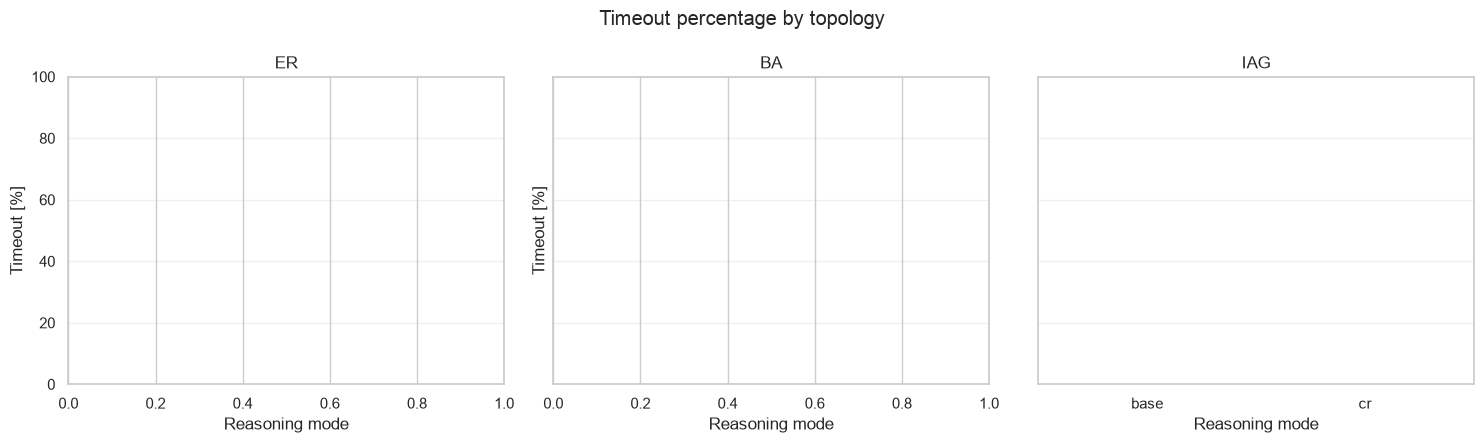

In [59]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)

for ax, topology in zip(axes, TOPOLOGIES):
    data = timeout_rate[timeout_rate["topology"] == topology]

    sns.barplot(
        data=data,
        x="mode",
        y="timeout_percentage",
        ax=ax,
    )

    ax.set_title(topology)
    ax.set_xlabel("Reasoning mode")
    ax.set_ylabel("Timeout [%]")
    ax.set_ylim(0, 100)
    ax.grid(True, axis="y", alpha=0.3)

fig.suptitle("Timeout percentage by topology")
fig.tight_layout()
plt.show()

## Timeout trend over simulation steps

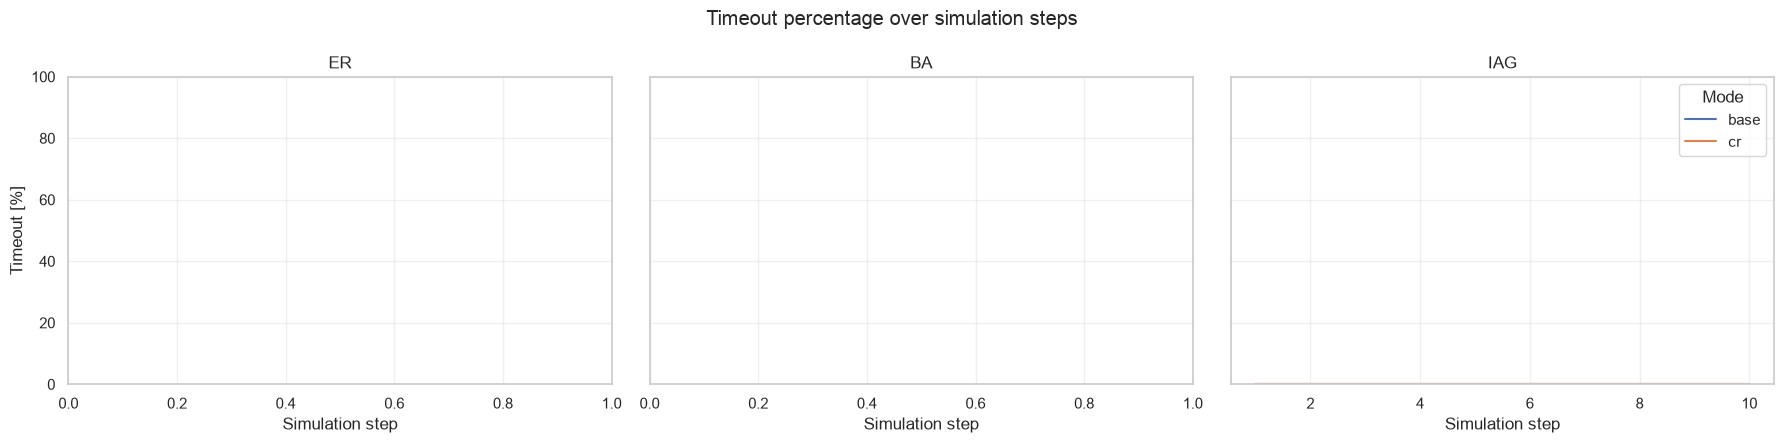

In [60]:
timeout_trend = (
    timeout_analysis.groupby(["topology", "mode", "n_event"], as_index=False)
    .agg(timeout_percentage=("query_timeout", lambda x: 100 * x.mean()))
)

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), sharey=True)

for ax, topology in zip(axes, TOPOLOGIES):
    data = timeout_trend[timeout_trend["topology"] == topology]

    sns.lineplot(
        data=data,
        x="n_event",
        y="timeout_percentage",
        hue="mode",
        ax=ax,
    )

    ax.set_title(topology)
    ax.set_xlabel("Simulation step")
    ax.set_ylabel("Timeout [%]")
    ax.set_ylim(0, 100)
    ax.grid(True, alpha=0.3)

    if ax.get_legend() is not None:
        ax.legend(title="Mode")

fig.suptitle("Timeout percentage over simulation steps")
fig.tight_layout()
plt.show()